In [173]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

import sys
sys.path.append("../")

def retime(df):
    """
    Recalculate segment time, treating the entire dataframe as one segment.

    Args:
        df (pd.DataFrame): Measurement data. Includes a column
                           'Segment Time, S'

    Returns:
        pd.DataFrame: Dataframe where 'Segment Time, S' is reindexed
                      to start from 0.
    """
    df_ = df.copy().reset_index(drop=True)
    df_["Segment Time, S"] = df_["Total Time, S"] - df_.loc[0, "Total Time, S"]
    return df_

hdf = pd.HDFStore('../../data/data_raw.h5', mode='r')
keys = hdf.keys()

In [174]:
idx_A = np.nonzero(["_A_" in key for key in keys])
df = hdf.get(keys[idx_A[0][0]])

In [175]:
segments_of_interest = [
    "Charge depleting cycle",
    "Charge sustaining cycle",
    'Rate test C/2 cycle charge CC',
    'PsRP 1 C/2 diagnostic cycle charge',
    'PsRP 2 C/2 diagnostic cycle charge',
    'Rate test 1C cycle charge CC',
    'PsRP 1 1C diagnostic cycle charge',
    'PsRP 2 1C diagnostic cycle charge',
]

Feature processing plan:
- "Charge depleting cycle",
    - has 10 minute repeats of power control
    - split into 10 minute windows (every 600 rows exactly)
    - for each window, extract final 2 minutes [:-120] for held out test set input
    - extract 5 random 120s windows from the first 8 minutes for training set input
    - target is C/3 discharge capacity
- "Charge sustaining cycle",
    - last 30 minutes pull out for held out test set input
    - first 1.5 hours, pull out 5 random 30 minute segments
- 'Rate test C/2 cycle charge CC',
    - grab 10x random 15 minute windows
- 'PsRP 1 C/2 diagnostic cycle charge',
    - grab 10x random 15 minute windows
- 'PsRP 2 C/2 diagnostic cycle charge',
    - grab 10x random 15 minute windows
- 'Rate test 1C cycle charge CC',
    - grab 10x random 8 minute windows
- 'PsRP 1 1C diagnostic cycle charge',
    - grab 10x random 8 minute windows
- 'PsRP 2 1C diagnostic cycle charge',
    - grab 10x random 8 minute windows

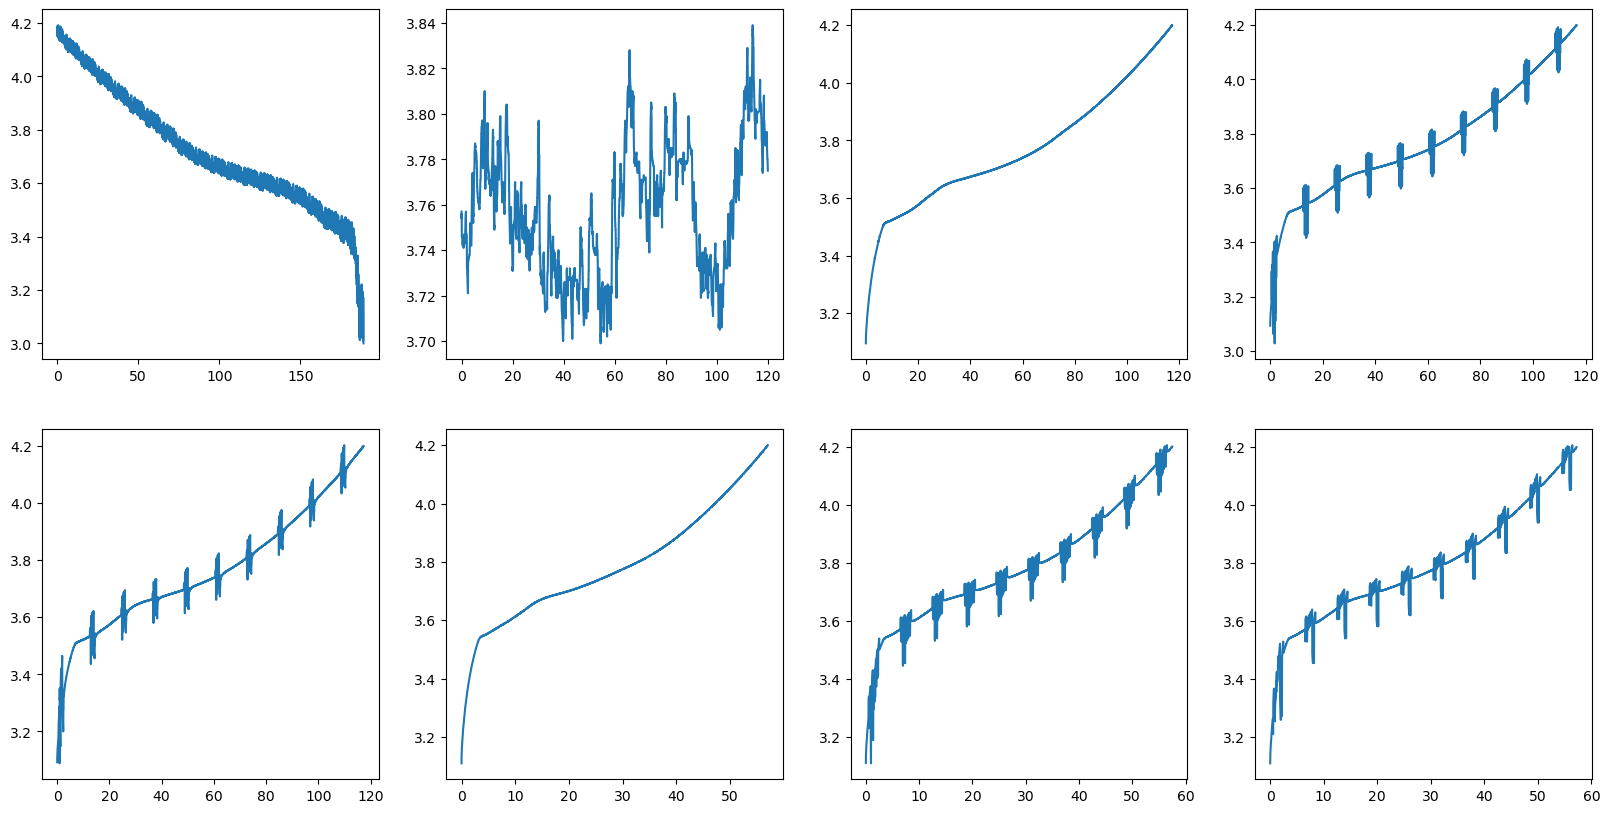

In [176]:
fig, ax = plt.subplots(2, 4, figsize=(20, 10))
ax = ax.flatten()
for i, segment in enumerate(segments_of_interest):
    # filter df for any rows where the col 'Segment Description' contains segment
    df_segment = df.loc[[segment in seg_desc and 'rest' not in seg_desc and 'CV' not in seg_desc for seg_desc in df['Segment Description']]]
    df_segment = retime(df_segment)
    ax[i].plot(df_segment['Segment Time, S'] / 60, df_segment['Voltage, V'])

In [177]:
df[df['Segment Description'].str.contains('Charge depleting cycle')]

,"Total Time, S",Cycle,Loop Counter #1,Loop Counter #2,Loop Counter #3,Step,"Step Time, S","Current, A","Voltage, V","Power, W","Amp-Hours, AH","Watt-Hours, WH","Temperature A1, °C",Mode,Real Time,Data Acquisition Flag,Segment Description,"Segment Time, S",SOC
276770,364303.7,1,1,1,1,198,1.0,-0.86,4.187,-3.6,0.00,0.00,31.5,DCHG,4/4/2023 6:48:47 PM,S,Charge depleting cycle,0.0,1.000000
276771,364304.7,1,1,1,1,199,1.0,-0.86,4.187,-3.6,0.00,0.00,31.5,DCHG,4/4/2023 6:48:48 PM,S,Charge depleting cycle,1.0,0.999996
276772,364305.7,1,1,1,1,200,1.0,-0.86,4.187,-3.6,0.00,0.00,31.5,DCHG,4/4/2023 6:48:49 PM,S,Charge depleting cycle,2.0,0.999993
276773,364306.7,1,1,1,1,201,1.0,-0.86,4.187,-3.6,0.00,0.00,31.5,DCHG,4/4/2023 6:48:50 PM,S,Charge depleting cycle,3.0,0.999989
276774,364307.7,1,1,1,1,202,1.0,-0.86,4.187,-3.6,0.00,0.00,31.5,DCHG,4/4/2023 6:48:51 PM,S,Charge depleting cycle,4.0,0.999985
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
288099,375632.7,1,1,1,1,745,1.0,-46.06,3.091,-142.2,-0.01,-0.03,33.0,DCHG,4/4/2023 9:57:35 PM,S,Charge depleting cycle,11329.0,0.000845
288100,375633.7,1,1,1,1,746,1.0,-53.86,3.067,-165.0,-0.01,-0.04,32.5,DCHG,4/4/2023 9:57:36 PM,S,Charge depleting cycle,11330.0,0.000628
288101,375634.7,1,1,1,1,747,1.0,-70.70,3.024,-213.6,-0.01,-0.05,32.5,DCHG,4/4/2023 9:57:37 PM,S,Charge depleting cycle,11331.0,0.000357
288102,375635.7,1,1,1,1,748,1.0,-66.19,3.008,-198.9,-0.01,-0.05,33.0,DCHG,4/4/2023 9:57:38 PM,S,Charge depleting cycle,11332.0,0.000060


In [178]:
# get 10 min segments from the charge sustaining cycle
def get_10_min_segments(df):
    df_segments = []
    _df_ = df.copy().reset_index(drop=True)
    _df_ = retime(_df_)
    _df_['Segment Time, S'] = _df_['Segment Time, S'].to_numpy().round().astype(int)
    t_start = 0
    t_end = 10 * 60
    discontinous = False
    while t_end < _df_['Segment Time, S'].max():
        _df_segment = retime(_df_[(_df_['Segment Time, S'] >= t_start) & (_df_['Segment Time, S'] < t_end)])
        if len(_df_segment) == 600:
            df_segments.append(_df_segment)
        elif len(_df_segment) > 600:
            #extra data points, remove everything with a decimal in the segment time
            _df_segment = _df_segment[_df_segment['Segment Time, S'] % 1 == 0]
            if len(_df_segment) == 600:
                print(f"removed extra data in segment starting at {t_start} seconds")
                df_segments.append(_df_segment)
            else:
                print(f"found extra data in 10 min segment starting at {t_start} seconds, unable to remove")
        else:
            print(f"found short segment starting at {t_start} seconds, only {len(_df_segment)} data points")
            discontinous = True
        t_start += 10 * 60
        t_end += 10 * 60
    return (df_segments, discontinous)

df = hdf.get('/A/data_230509_ReCellML_A_Cell15_charac_30C')

# For a measurement, return collated data from the charge-depleting cycle
if any(["Cell Voltage A1" in col for col in df.columns]):
    col_voltage = "Cell Voltage A1, V"
else:
    col_voltage = "Voltage, V"

is_cycle = [
    "Charge depleting cycle" in seg_desc for seg_desc in df["Segment Description"]
]

#split the repeating charge depleting cycles into individual 10 min cycles
dfs, discontinous = get_10_min_segments(df[is_cycle])
if discontinous:
    print(f"found discontinuity in /D/data_240820_ReCellML_A123_cell23_charac_30oC")
time = dfs[0]['Segment Time, S']

# mask_priorvoltage = [False] * len(is_cycle) # not sure this is needed
# len(is_cycle) - len(mask_priorvoltage)

for i, t in enumerate(time):
    if i == 0:
        # columns_soc = ["soc_%5.1fs" % (t)]
        columns_voltage = ["voltage_%5.1fs" % (t)]
        columns_current = ["current_%5.1fs" % (t)]
        columns_power = ["power_%5.1fs" % (t)]
    else:
        # columns_soc += ["soc_%5.1fs" % (t)]
        columns_voltage += ["voltage_%5.1fs" % (t)]
        columns_current += ["current_%5.1fs" % (t)]
        columns_power += ["power_%5.1fs" % (t)]

for i, df_seg in enumerate(dfs):
    if i == 0:
        soc_mean = df_seg.SOC.to_numpy().mean()
        soc_initial = df_seg.SOC.to_numpy()[0]
        soc_final = df_seg.SOC.to_numpy()[-1]
        temperature = np.mean(df_seg["Temperature A1, °C"].to_numpy())
        voltage = df_seg[col_voltage].to_numpy()
        current = df_seg["Current, A"].to_numpy()
        power = df_seg["Power, W"].to_numpy()
    else:
        soc_mean = np.vstack((soc_mean, df_seg.SOC.to_numpy().mean()))
        soc_initial = np.vstack((soc_initial, df_seg.SOC.to_numpy()[0]))
        soc_final = np.vstack((soc_final, df_seg.SOC.to_numpy()[-1]))
        temperature = np.vstack((temperature, np.mean(df_seg["Temperature A1, °C"].to_numpy())))
        voltage = np.vstack((voltage, df_seg[col_voltage].to_numpy()))
        current = np.vstack((current, df_seg["Current, A"].to_numpy()))
        power = np.vstack((power, df_seg["Power, W"].to_numpy()))

out = np.hstack((temperature, soc_mean, soc_initial, soc_final, voltage, current, power))
columns = (["temperature", "soc_mean", "soc_initial", "soc_final"] + columns_voltage + columns_current + columns_power)

df_out = pd.DataFrame(out, columns=columns)
df_out

removed extra data in segment starting at 4200 seconds
removed extra data in segment starting at 4800 seconds
removed extra data in segment starting at 5400 seconds


,temperature,soc_mean,soc_initial,soc_final,voltage_ 0.0s,voltage_ 1.0s,voltage_ 2.0s,voltage_ 3.0s,voltage_ 4.0s,voltage_ 5.0s,...,power_590.0s,power_591.0s,power_592.0s,power_593.0s,power_594.0s,power_595.0s,power_596.0s,power_597.0s,power_598.0s,power_599.0s
0,29.500000,0.974292,1.000000,0.952969,4.188,4.188,4.188,4.188,4.188,4.187,...,58.6,35.4,1.4,-3.8,-3.6,-3.6,-3.6,-3.6,-3.6,-3.6
1,29.500000,0.926765,0.952965,0.905182,4.119,4.119,4.119,4.119,4.118,4.118,...,35.4,1.2,-3.8,-3.4,-3.4,-3.4,-3.4,-3.4,-3.4,-3.4
2,29.517500,0.878507,0.905178,0.856678,4.059,4.059,4.059,4.058,4.058,4.059,...,1.2,-3.8,-3.6,-3.6,-3.6,-3.6,-3.6,-3.6,-3.6,-3.6
3,29.717500,0.829538,0.856674,0.807474,4.002,4.002,4.002,4.002,4.002,4.002,...,-3.8,-3.6,-3.6,-3.6,-3.6,-3.6,-3.6,-3.6,-3.6,-3.6
4,29.925000,0.779876,0.807470,0.757585,3.949,3.948,3.949,3.949,3.949,3.943,...,-3.4,-3.4,-3.4,-3.4,-3.4,-3.4,-3.4,-3.4,-3.4,-3.4
5,29.995833,0.729534,0.757577,0.707019,3.897,3.898,3.898,3.898,3.892,3.867,...,-3.6,-3.6,-3.6,-3.6,-3.6,-3.6,-3.6,-3.6,-3.6,-10.2
6,29.999167,0.678519,0.707009,0.655779,3.850,3.850,3.850,3.843,3.819,3.812,...,-3.4,-3.4,-3.4,-3.4,-3.4,-3.4,-3.4,-3.4,-10.0,-6.6
7,29.993333,0.626832,0.655772,0.603854,3.801,3.801,3.795,3.770,3.763,3.761,...,-3.4,-3.4,-3.4,-3.4,-3.4,-3.4,-3.4,-10.0,-6.8,-5.7
8,29.836667,0.574431,0.603847,0.551267,3.745,3.739,3.713,3.707,3.705,3.714,...,-3.6,-3.6,-3.6,-3.6,-3.6,-3.6,-10.2,-6.8,-5.8,-6.3
9,29.526667,0.521490,0.551237,0.498182,3.699,3.673,3.667,3.665,3.675,3.666,...,-3.6,-3.6,-3.6,-3.6,-3.6,-10.2,-6.6,-5.9,-6.4,-44.6


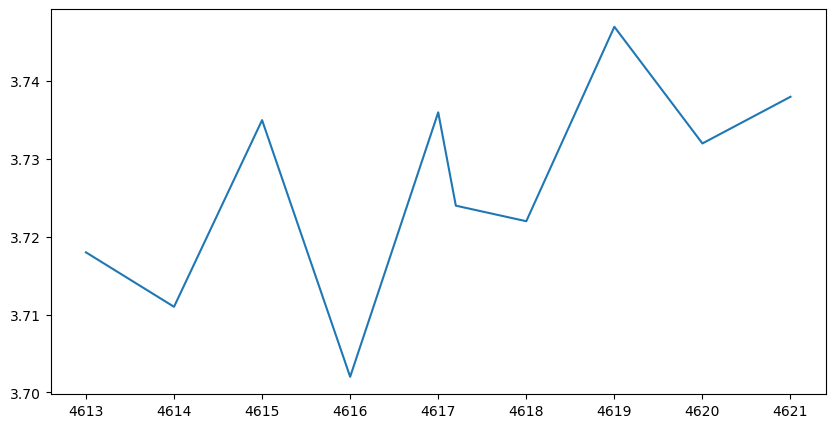

In [179]:
# Some datasets have extra data points in the cycle

df = hdf.get('/A/data_230509_ReCellML_A_Cell15_charac_30C')

df[df['Segment Description'].str.contains('Charge depleting cycle')]

time = df[df['Segment Description'].str.contains('Charge depleting cycle')]['Segment Time, S']

fig, ax = plt.subplots(figsize=(10, 5))
section = df[(df['Total Time, S'] >=369725.6) & (df['Total Time, S'] <= 369733.6)]
ax.plot(section['Segment Time, S'], section[col_voltage])
# ax.plot(range(len(time)), time / 60)

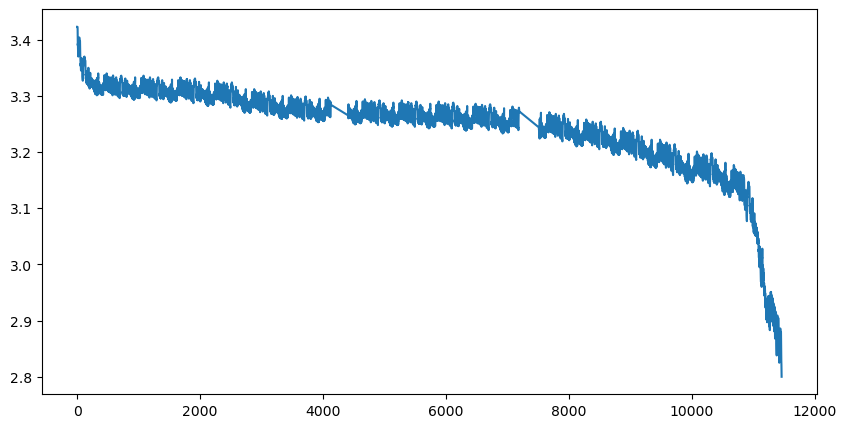

In [180]:
df = hdf.get('/D/data_240820_ReCellML_A123_cell27_charac_30oC')

df = df[df['Segment Description'].str.contains('Charge depleting cycle')]
df = retime(df)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df['Segment Time, S'], df[col_voltage])

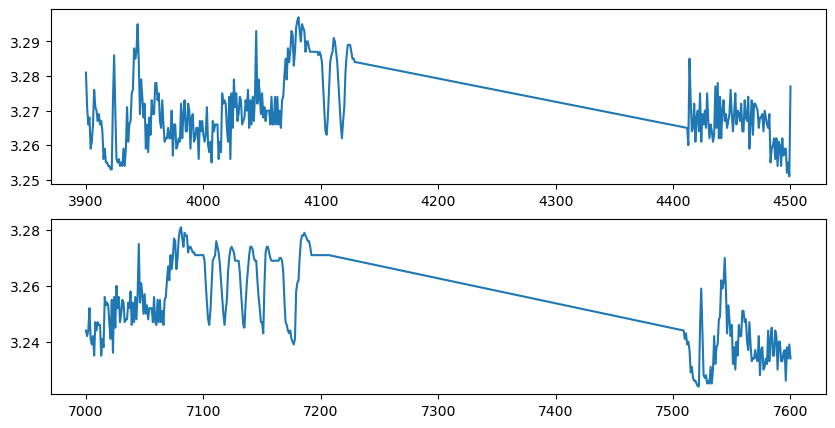

In [181]:
df = df[df['Segment Description'].str.contains('Charge depleting cycle')]
df = retime(df)

fig, ax = plt.subplots(2, 1, figsize=(10, 5))
ax = ax.flatten()
df1 = df[df['Segment Time, S'].between(3900, 4500)]
df2 = df[df['Segment Time, S'].between(7000, 7600)]
ax[0].plot(df1['Segment Time, S'], df1[col_voltage])
ax[1].plot(df2['Segment Time, S'], df2[col_voltage])

C:\Users\etenney\AppData\Local\Temp\1\ipykernel_11160\3056413589.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', 4)
C:\Users\etenney\AppData\Local\Temp\1\ipykernel_11160\3056413589.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_first['cell_type'] = [id[0] for id in df_first['cell_id']]


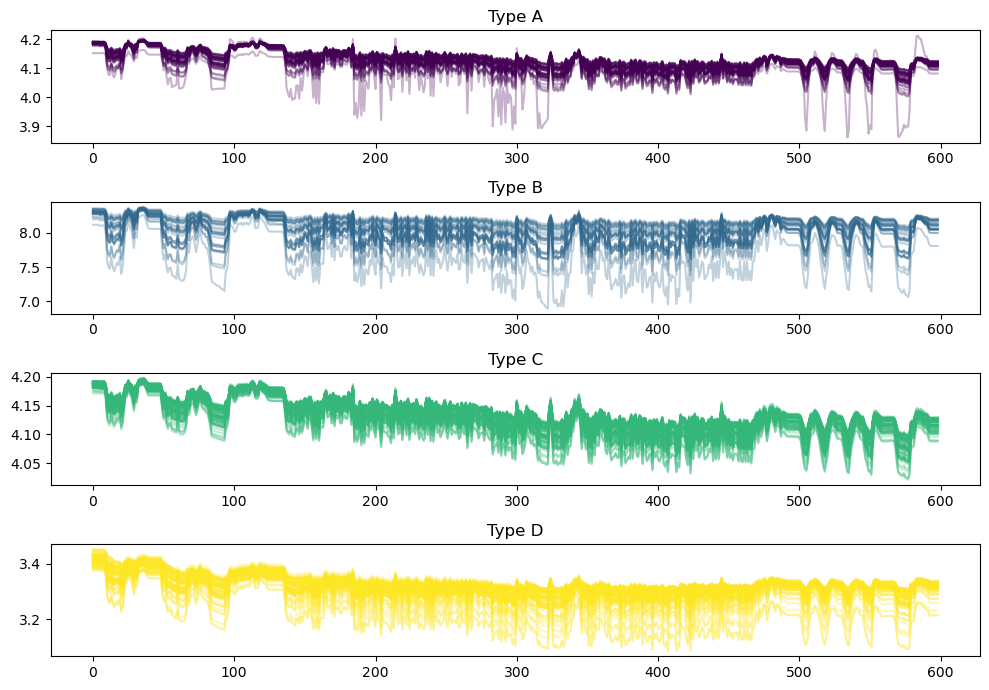

In [183]:
df = pd.read_csv('../../data/features_charge_depleting_cycles.csv')
df_first = df[df['soc_initial'] == 1.0]

import matplotlib.cm as cm
import seaborn as sns
cmap = cm.get_cmap('viridis', 4)

df_first['cell_type'] = [id[0] for id in df_first['cell_id']]

type_map = {
    'A': 0,
    'B': 1,
    'C': 2,
    'D': 3
}
fig, ax = plt.subplots(4, 1, figsize=(10, 7))
for i, row in df_first.iterrows():
    ax[type_map[row.cell_type]].plot(range(599), row.filter(regex='^voltage'), alpha=0.3, c = cmap(type_map[row.cell_type]))
# df_first
ax[0].set_title('Type A')
ax[1].set_title('Type B')
ax[2].set_title('Type C')
ax[3].set_title('Type D')

fig.tight_layout()

# ax = sns.relplot(data=df_first,x='Segment Time, T', y='', legend=False, alpha=0.3, col="cell_type", kind='line')

C:\Users\etenney\AppData\Local\Temp\1\ipykernel_11160\3806608481.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', 100)


Text(0.5, 1.0, 'Type A charge depleting cycle voltage profiles colored by SOC')

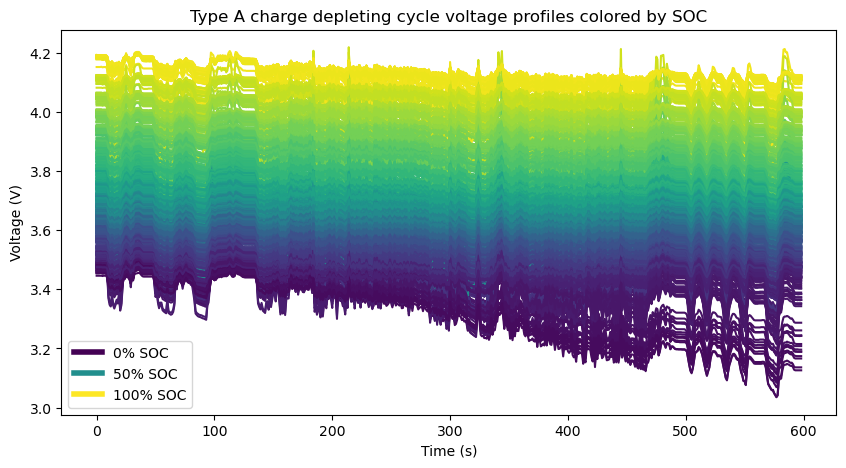

In [186]:
df_a = df[df['cell_id'].str.contains('A')]
cmap = cm.get_cmap('viridis', 100)
plt.figure(figsize=(10, 5))
for i, row in df_a.iterrows():
    plt.plot(range(599), row.filter(regex='^voltage'), alpha=1, c=cmap(row['soc_mean']))
    
plt.legend(handles=[plt.Line2D([0], [0], color=cmap(0), lw=4, label='0% SOC'),
                    plt.Line2D([0], [0], color=cmap(49), lw=4, label='50% SOC'),
                    plt.Line2D([0], [0], color=cmap(99), lw=4, label='100% SOC')])
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Type A charge depleting cycle voltage profiles colored by SOC')

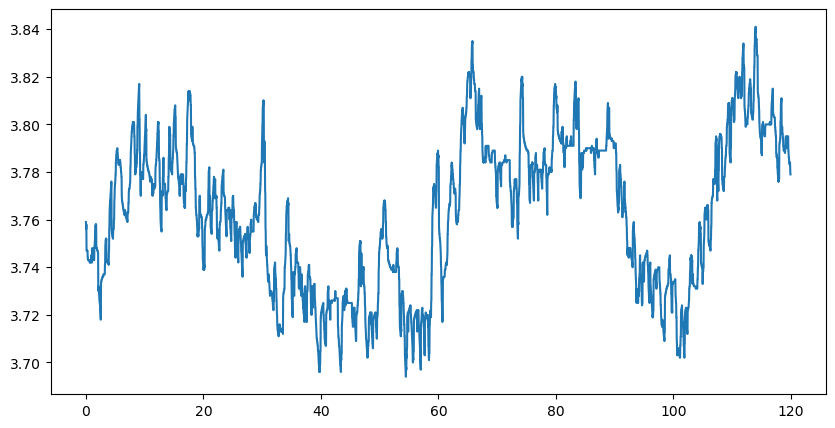

In [ ]:
df = hdf.get('/A/data_230509_ReCellML_A_Cell15_charac_30C')
df = df[df['Segment Description'].str.contains('Charge sustaining cycle')]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df['Segment Time, S'] / 60, df['Voltage, V'])

In [ ]:
df = hdf.get('/D/data_240624_ReCellML_A123_Cell01_charac_30C')
df = df[df['Segment Description'].str.contains('Charge sustaining cycle')]

if any(["Cell Voltage A1" in col for col in df.columns]):
    col_voltage = "Cell Voltage A1, V"
else:
    col_voltage = "Voltage, V"

is_cycle = [
    "Charge sustaining cycle" in seg_desc for seg_desc in df["Segment Description"]
]

time = df['Segment Time, S']
df_seg = df[is_cycle]

# mask_priorvoltage = [False] * len(is_cycle) # not sure this is needed
# len(is_cycle) - len(mask_priorvoltage)

for i, t in enumerate(time):
    if i == 0:
        columns_soc = ["soc_%5.1fs" % (t)]
        columns_voltage = ["voltage_%5.1fs" % (t)]
        columns_current = ["current_%5.1fs" % (t)]
        columns_power = ["power_%5.1fs" % (t)]
    else:
        columns_soc += ["soc_%5.1fs" % (t)]
        columns_voltage += ["voltage_%5.1fs" % (t)]
        columns_current += ["current_%5.1fs" % (t)]
        columns_power += ["power_%5.1fs" % (t)]

# for i, df_seg in enumerate(df[is_cycle]):
#     if i == 0:
soc = df_seg.SOC.to_numpy()
# temperature = df_seg["Temperature A1, °C"].to_numpy()
temperature = np.mean(df_seg["Temperature A1, °C"].to_numpy())
voltage = df_seg[col_voltage].to_numpy()
current = df_seg["Current, A"].to_numpy()
power = df_seg["Power, W"].to_numpy()
    # else:
    #     soc = np.vstack((soc, df_seg.SOC.to_numpy()))
    #     # temperature = np.vstack((temperature, df_seg["Temperature A1, °C"].to_numpy()))
    #     temperature = np.vstack((temperature, np.mean(df_seg["Temperature A1, °C"].to_numpy())))
    #     voltage = np.vstack((voltage, df_seg[col_voltage].to_numpy()))
    #     current = np.vstack((current, df_seg["Current, A"].to_numpy()))
    #     power = np.vstack((power, df_seg["Power, W"].to_numpy()))

out = np.hstack((temperature, soc , voltage, current, power))
columns = (["temperature"] + columns_soc + columns_voltage + columns_current + columns_power)
# soc
out
# columns
df_out = pd.Series(out, index=columns)

pd.DataFrame([df_out])

,temperature,soc_ 0.0s,soc_ 4.0s,soc_ 8.0s,soc_ 12.0s,soc_ 16.0s,soc_ 20.0s,soc_ 24.0s,soc_ 28.0s,soc_ 32.0s,...,power_7160.0s,power_7164.0s,power_7168.0s,power_7172.0s,power_7176.0s,power_7180.0s,power_7184.0s,power_7188.0s,power_7192.0s,power_7196.0s
0,29.827222,-0.285465,-0.285928,-0.286181,-0.286278,-0.286368,-0.28641,-0.28641,-0.28641,-0.28641,...,-0.8,0.0,0.0,0.0,-1.1,-1.5,-1.7,-1.7,-1.6,-2.3


In [ ]:
df = hdf.get('/A/data_230509_ReCellML_A_Cell15_charac_30C')

df = df[df['Segment Description'].str.contains('Charge sustaining cycle')]
df

,"Total Time, S",Cycle,Loop Counter #1,Loop Counter #2,Loop Counter #3,Step,"Step Time, S","Current, A","Voltage, V","Power, W","Amp-Hours, AH","Watt-Hours, WH","Temperature A1, °C",Mode,Real Time,Data Acquisition Flag,Segment Description,"Segment Time, S",SOC
291910,385508.4,1,1,1,1,797,1.0,30.57,3.759,114.8,0.00,0.03,29.5,CHRG,5/14/2023 12:06:48 AM,S,Charge sustaining cycle,0.0,0.582952
291911,385509.4,1,1,1,1,798,1.0,23.90,3.756,89.6,0.00,0.02,29.5,CHRG,5/14/2023 12:06:49 AM,,Charge sustaining cycle,1.0,0.583068
291912,385510.4,1,1,1,1,798,2.0,23.90,3.756,89.6,0.01,0.04,29.5,CHRG,5/14/2023 12:06:50 AM,,Charge sustaining cycle,2.0,0.583170
291913,385511.4,1,1,1,1,798,3.0,23.90,3.757,89.6,0.01,0.07,29.5,CHRG,5/14/2023 12:06:51 AM,,Charge sustaining cycle,3.0,0.583272
291914,385512.4,1,1,1,1,798,4.0,23.90,3.758,89.8,0.02,0.09,29.5,CHRG,5/14/2023 12:06:52 AM,S,Charge sustaining cycle,4.0,0.583373
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299102,392700.4,1,1,1,1,2595,4.0,-13.14,3.783,-49.6,-0.01,-0.05,29.5,DCHG,5/14/2023 2:06:40 AM,S,Charge sustaining cycle,7192.0,0.627973
299103,392701.4,1,1,1,1,2596,1.0,-18.39,3.780,-69.5,0.00,-0.01,29.5,DCHG,5/14/2023 2:06:41 AM,,Charge sustaining cycle,7193.0,0.627905
299104,392702.4,1,1,1,1,2596,2.0,-18.39,3.780,-69.5,-0.01,-0.03,29.5,DCHG,5/14/2023 2:06:42 AM,,Charge sustaining cycle,7194.0,0.627827
299105,392703.4,1,1,1,1,2596,3.0,-18.39,3.779,-69.4,-0.01,-0.05,29.5,DCHG,5/14/2023 2:06:43 AM,,Charge sustaining cycle,7195.0,0.627749


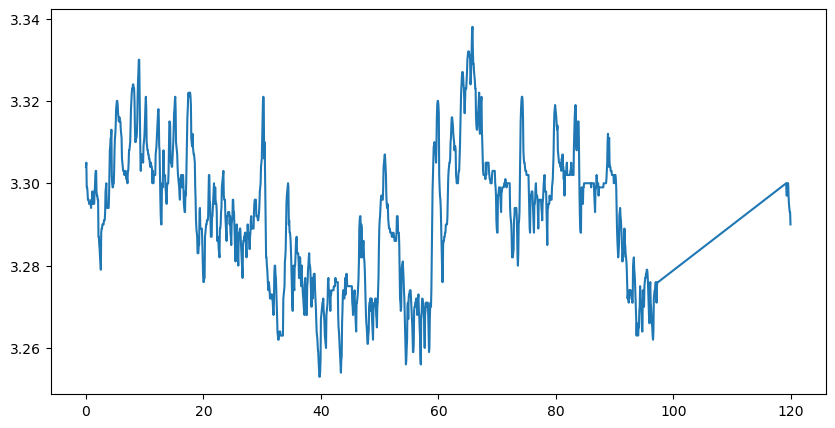

In [199]:
df = hdf.get('/D/data_240626_ReCellML_A123_Cell04_charac_30C')

df = df[df['Segment Description'].str.contains('Charge sustaining cycle')]
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df['Segment Time, S'] / 60, df['Voltage, V'])